# FER2013 Manual Preprocessing Notebook

This notebook creates new preprocessed dataset folders:

```text
train_new/
test_new/
```

It includes manual preprocessing blocks:

1. Light noise removal
2. Histogram equalization
3. Normalization
4. Sharpening
5. Data augmentation for the `surprise/surprised` class only

No OpenCV is used.


In [170]:
# =========================
# 1. Imports and paths
# =========================

import os
import math
import shutil
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Change this path based on your dataset location
DATASET_ROOT = Path(r"C:\Users\nadee\Downloads\Emotion-Recognition\archive")

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

TRAIN_NEW_DIR = DATASET_ROOT / "train_new"
TEST_NEW_DIR = DATASET_ROOT / "test_new"

IMAGE_SIZE = (48, 48)

# FER2013 class folder names are usually:
# angry, disgust, fear, happy, neutral, sad, surprise
TARGET_AUG_CLASS_NAMES = ["surprise", "surprised"]

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)
print("Train new path:", TRAIN_NEW_DIR)
print("Test new path:", TEST_NEW_DIR)


Train path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\train
Test path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\test
Train new path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\train_new
Test new path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\test_new


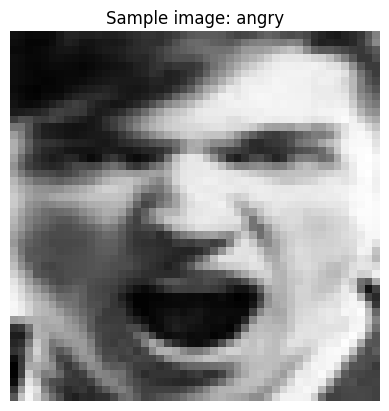

In [171]:
# =========================
# 2. Helper functions
# =========================

def load_grayscale_image(path, size=(48, 48)):
    img = Image.open(path).convert("L")
    img = img.resize(size)
    return np.array(img, dtype=np.float32)

def save_grayscale_image(array, path):
    array = np.clip(array, 0, 255).astype(np.uint8)
    img = Image.fromarray(array, mode="L")
    path.parent.mkdir(parents=True, exist_ok=True)
    img.save(path)

def show_before_after(before, after, title):
    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(before, cmap="gray")
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(after, cmap="gray")
    plt.title("After: " + title)
    plt.axis("off")

    plt.show()

def get_first_image_from_train():
    for class_folder in TRAIN_DIR.iterdir():
        if class_folder.is_dir():
            images = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.png")) + list(class_folder.glob("*.jpeg"))
            if images:
                return images[0]
    raise FileNotFoundError("No images found in train folder.")

sample_path = get_first_image_from_train()
sample_img = load_grayscale_image(sample_path, IMAGE_SIZE)

plt.imshow(sample_img, cmap="gray")
plt.title(f"Sample image: {sample_path.parent.name}")
plt.axis("off")
plt.show()


## Block 2 — Manual histogram equalization

This improves contrast manually using histogram, cumulative distribution, and pixel mapping.


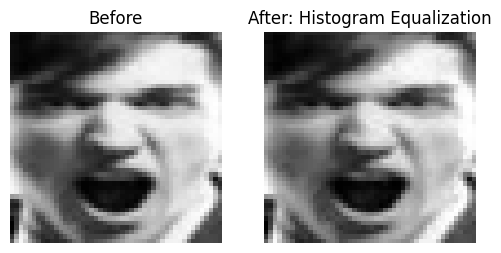

In [172]:
# =========================
# 4. Manual histogram equalization
# =========================

def manual_histogram_equalization(img):
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)

    # Count frequency of each pixel value from 0 to 255
    histogram = np.zeros(256, dtype=np.int32)
    h, w = img_uint8.shape

    for y in range(h):
        for x in range(w):
            pixel_value = img_uint8[y, x]
            histogram[pixel_value] += 1

    # Cumulative distribution function
    cdf = np.zeros(256, dtype=np.float32)
    cdf[0] = histogram[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + histogram[i]

    non_zero_cdf = cdf[cdf > 0]
    if len(non_zero_cdf) == 0:
        return img_uint8.astype(np.float32)

    cdf_min = non_zero_cdf[0]
    total_pixels = h * w

    if total_pixels == cdf_min:
        return img_uint8.astype(np.float32)

    mapping = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        mapped_value = ((cdf[i] - cdf_min) / (total_pixels - cdf_min)) * 255
        mapping[i] = np.clip(round(mapped_value), 0, 255)

    # Apply mapping
    output = np.zeros_like(img_uint8, dtype=np.float32)
    for y in range(h):
        for x in range(w):
            output[y, x] = mapping[img_uint8[y, x]]

    return output

hist_example = manual_histogram_equalization(sample_img)
show_before_after(sample_img, hist_example, "Histogram Equalization")


## Block 3 — Manual normalization

This manually scales pixel values to the range 0–255 after using min-max normalization.

For saving as images, we save back as 0–255.


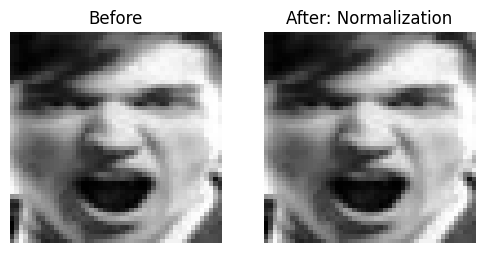

In [173]:
# =========================
# 5. Manual normalization
# =========================

def manual_normalization_to_0_1(img):
    min_val = np.min(img)
    max_val = np.max(img)

    if max_val - min_val == 0:
        return np.zeros_like(img, dtype=np.float32)

    normalized = (img - min_val) / (max_val - min_val)
    return normalized


def manual_normalization_to_255(img):
    normalized_0_1 = manual_normalization_to_0_1(img)
    normalized_255 = normalized_0_1 * 255.0
    return normalized_255


norm_example = manual_normalization_to_255(hist_example)
show_before_after(hist_example, norm_example, "Normalization")

## Block 4 — Manual sharpening

This uses a manual sharpening convolution kernel:

```text
 0 -1  0
-1  5 -1
 0 -1  0
```


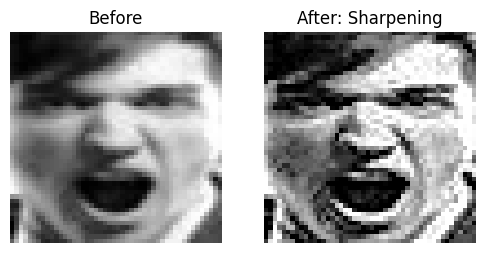

In [174]:
# =========================
# 6. Manual sharpening
# =========================

def manual_sharpening(img):
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32)

    h, w = img.shape
    padded = np.pad(img, pad_width=1, mode="edge")
    output = np.zeros_like(img, dtype=np.float32)

    for y in range(h):
        for x in range(w):
            region = padded[y:y+3, x:x+3]
            output[y, x] = np.sum(region * kernel)

    output = np.clip(output, 0, 255)
    return output

sharp_example = manual_sharpening(norm_example)
show_before_after(norm_example, sharp_example, "Sharpening")


## Block 5 — Full preprocessing pipeline

This function applies the preprocessing steps in order:

```text
noise removal → histogram equalization → normalization → sharpening
```


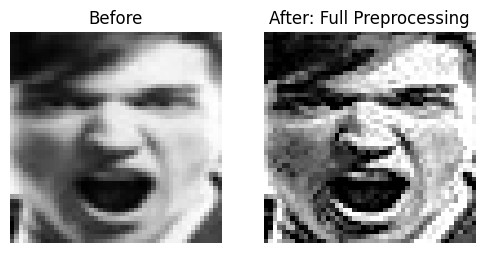

In [175]:
# =========================
# 7. Full preprocessing function
# =========================

def preprocess_image(img):
    img = manual_histogram_equalization(img)
    img = manual_normalization_to_255(img)
    img = manual_sharpening(img)
    return img

full_example = preprocess_image(sample_img)
show_before_after(sample_img, full_example, "Full Preprocessing")

## Block 6 — Manual augmentation for `surprise/surprised` class only

This augmentation is manual and only used for the training set.

Augmentation types:
1. Horizontal flip
2. Small manual shift
3. Manual brightness increase
4. Manual brightness decrease

Only images inside the `surprise` or `surprised` folder are augmented.


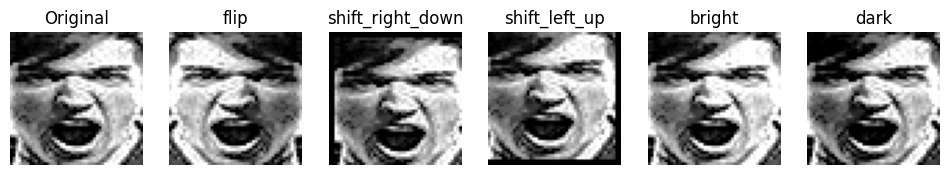

In [176]:
# =========================
# 8. Manual augmentation functions
# =========================

def manual_horizontal_flip(img):
    return img[:, ::-1]

def manual_shift(img, shift_y=2, shift_x=2):
    h, w = img.shape
    output = np.zeros_like(img)

    for y in range(h):
        for x in range(w):
            new_y = y + shift_y
            new_x = x + shift_x

            if 0 <= new_y < h and 0 <= new_x < w:
                output[new_y, new_x] = img[y, x]

    return output

def manual_brightness(img, value=20):
    output = img + value
    output = np.clip(output, 0, 255)
    return output

def create_manual_augmentations(img):
    augmented = []

    augmented.append(("flip", manual_horizontal_flip(img)))
    augmented.append(("shift_right_down", manual_shift(img, shift_y=2, shift_x=2)))
    augmented.append(("shift_left_up", manual_shift(img, shift_y=-2, shift_x=-2)))
    augmented.append(("bright", manual_brightness(img, value=20)))
    augmented.append(("dark", manual_brightness(img, value=-20)))

    return augmented

aug_examples = create_manual_augmentations(full_example)

plt.figure(figsize=(12, 3))
plt.subplot(1, 6, 1)
plt.imshow(full_example, cmap="gray")
plt.title("Original")
plt.axis("off")

for i, (name, aug_img) in enumerate(aug_examples, start=2):
    plt.subplot(1, 6, i)
    plt.imshow(aug_img, cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.show()


## Block 7 — Save new train_new and test_new folders

This block:
1. Reads images from `train/` and `test/`
2. Applies manual preprocessing
3. Saves results to `train_new/` and `test_new/`
4. Applies augmentation only to `surprise/surprised` class in `train_new/`


In [177]:
# =========================
# 9. Save processed train_new and test_new
# =========================

MAX_TARGET_COUNT = 4600   # target count for augmented classes

TARGET_AUG_CLASS_NAMES = {
    "angry",
    "fearful",
    "fear",
    "neutral",
    "sad",
    "surprised",
    "surprise"
}

def get_image_files(folder):
    files = []
    files.extend(folder.glob("*.jpg"))
    files.extend(folder.glob("*.jpeg"))
    files.extend(folder.glob("*.png"))
    return files


def clear_folder(folder):
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)


def process_dataset_folder(input_dir, output_dir, augment_train=False):
    total_saved = 0
    total_augmented = 0

    clear_folder(output_dir)

    class_folders = [f for f in input_dir.iterdir() if f.is_dir()]

    for class_folder in class_folders:
        class_name = class_folder.name
        class_name_lower = class_name.lower()

        output_class_folder = output_dir / class_name
        output_class_folder.mkdir(parents=True, exist_ok=True)

        image_files = get_image_files(class_folder)

        print(f"Processing class: {class_name} | Images: {len(image_files)}")

        # Save original processed images first
        for img_path in image_files:
            img = load_grayscale_image(img_path, IMAGE_SIZE)
            processed = preprocess_image(img)

            save_path = output_class_folder / img_path.name
            save_grayscale_image(processed, save_path)

            total_saved += 1

        # Augment selected classes only in training set
        if augment_train and class_name_lower in TARGET_AUG_CLASS_NAMES:
            current_count = len(get_image_files(output_class_folder))

            print(f"Augmenting {class_name} from {current_count} to {MAX_TARGET_COUNT}")

            while current_count < MAX_TARGET_COUNT:
                for img_path in image_files:
                    if current_count >= MAX_TARGET_COUNT:
                        break

                    img = load_grayscale_image(img_path, IMAGE_SIZE)
                    processed = preprocess_image(img)

                    augmented_images = create_manual_augmentations(processed)

                    for aug_name, aug_img in augmented_images:
                        if current_count >= MAX_TARGET_COUNT:
                            break

                        aug_save_name = f"{img_path.stem}_aug_{current_count}_{aug_name}{img_path.suffix}"
                        aug_save_path = output_class_folder / aug_save_name

                        save_grayscale_image(aug_img, aug_save_path)

                        total_augmented += 1
                        current_count += 1

            print(f"{class_name} final count: {current_count}")

        else:
            print(f"{class_name} not augmented.")

    print("Done.")
    print("Original processed images saved:", total_saved)
    print("Extra augmented images saved:", total_augmented)


# Process train with augmentation for selected classes
process_dataset_folder(
    input_dir=TRAIN_DIR,
    output_dir=TRAIN_NEW_DIR,
    augment_train=True
)

# Process test without augmentation
process_dataset_folder(
    input_dir=TEST_DIR,
    output_dir=TEST_NEW_DIR,
    augment_train=False
)

Processing class: angry | Images: 705
Augmenting angry from 705 to 4600
angry final count: 4600
Processing class: fearful | Images: 281
Augmenting fearful from 281 to 4600
fearful final count: 4600
Processing class: happy | Images: 4772
happy not augmented.
Processing class: neutral | Images: 2524
Augmenting neutral from 2524 to 4600
neutral final count: 4600
Processing class: sad | Images: 1982
Augmenting sad from 1982 to 4600
sad final count: 4600
Processing class: surprised | Images: 1290
Augmenting surprised from 1290 to 4600
surprised final count: 4600
Done.
Original processed images saved: 11554
Extra augmented images saved: 16218
Processing class: angry | Images: 162
angry not augmented.
Processing class: fearful | Images: 74
fearful not augmented.
Processing class: happy | Images: 1185
happy not augmented.
Processing class: neutral | Images: 680
neutral not augmented.
Processing class: sad | Images: 478
sad not augmented.
Processing class: surprised | Images: 329
surprised not 

## Block 8 — Check new class counts

This confirms how many images are inside each new folder.


In [178]:
# =========================
# 10. Check class counts
# =========================

def count_images_per_class(folder):
    counts = {}
    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            counts[class_folder.name] = len(get_image_files(class_folder))
    return counts

print("Train_new counts:")
train_counts = count_images_per_class(TRAIN_NEW_DIR)
for cls, count in train_counts.items():
    print(cls, ":", count)

print("\nTest_new counts:")
test_counts = count_images_per_class(TEST_NEW_DIR)
for cls, count in test_counts.items():
    print(cls, ":", count)


Train_new counts:
angry : 4600
fearful : 4600
happy : 4772
neutral : 4600
sad : 4600
surprised : 4600

Test_new counts:
angry : 162
fearful : 74
happy : 1185
neutral : 680
sad : 478
surprised : 329


## Block 9 — Use the new folders in training

Use these paths in your training notebook:

```python
train_path = r".../archive/train_new"
test_path = r".../archive/test_new"
```


In [179]:
# =========================
# 11. Paths to use in model training
# =========================

print("Use this as your new train path:")
print(TRAIN_NEW_DIR)

print("\nUse this as your new test path:")
print(TEST_NEW_DIR)


Use this as your new train path:
C:\Users\nadee\Downloads\Emotion-Recognition\archive\train_new

Use this as your new test path:
C:\Users\nadee\Downloads\Emotion-Recognition\archive\test_new
